In [3]:
pip install --upgrade pyarrow pandas

   ---------------------------------------- 0.0/27.3 MB ? eta -:--:--
    --------------------------------------- 0.6/27.3 MB 12.7 MB/s eta 0:00:03
   - -------------------------------------- 1.0/27.3 MB 10.4 MB/s eta 0:00:03
   -- ------------------------------------- 1.6/27.3 MB 11.2 MB/s eta 0:00:03
   --- ------------------------------------ 2.3/27.3 MB 12.2 MB/s eta 0:00:03
   --- ------------------------------------ 2.6/27.3 MB 11.8 MB/s eta 0:00:03
   ---- ----------------------------------- 2.8/27.3 MB 10.1 MB/s eta 0:00:03
   ----- ---------------------------------- 3.5/27.3 MB 10.7 MB/s eta 0:00:03
   ----- ---------------------------------- 4.1/27.3 MB 10.8 MB/s eta 0:00:03
   ------ --------------------------------- 4.5/27.3 MB 10.8 MB/s eta 0:00:03
   ------- -------------------------------- 5.1/27.3 MB 10.8 MB/s eta 0:00:03
   ------- -------------------------------- 5.3/27.3 MB 10.3 MB/s eta 0:00:03
   -------- ------------------------------- 6.0/27.3 MB 10.7 MB/s eta 0:

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.30.0 requires numpy<2,>=1.19.3, but you have numpy 2.4.1 which is incompatible.
streamlit 1.30.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.3 which is incompatible.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 6.32.1 which is incompatible.


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import requests

In [5]:
path="train.csv"
# Read the CSV file into a Pandas DataFrame
data = pd.read_csv(path)
df=pd.DataFrame(data)
# Display the first few rows of the DataFrame
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFlaggedFraud,isFraud
0,619,CASH_IN,386385.08,C421351828,4669568.85,5055953.92,C1977099364,506035.06,119649.98,0,0
1,164,CASH_IN,212458.78,C83569848,234635.00,447093.78,C1690589535,806037.88,593579.10,0,0
2,382,PAYMENT,19967.60,C852995095,3634.00,0.00,M1695416333,0.00,0.00,0,0
3,180,CASH_OUT,527616.51,C61761046,180216.00,0.00,C577654587,92157.10,619773.61,0,0
4,36,TRANSFER,206067.85,C758004147,0.00,0.00,C2143015292,2131494.48,2337562.32,0,0
5,323,PAYMENT,141.42,C1324973164,174.00,32.58,M304838505,0.00,0.00,0,0
6,10,CASH_OUT,15241.42,C1606904496,45285.00,30043.58,C36437323,355775.87,652863.91,0,0
7,263,PAYMENT,5292.90,C192639813,257.00,0.00,M1055957644,0.00,0.00,0,0
8,278,CASH_IN,97648.62,C526735861,2936326.20,3033974.82,C1328992387,1640348.29,1542699.67,0,0
9,331,CASH_IN,284341.53,C1517313722,8133378.48,8417720.01,C890006563,5702766.00,5418424.47,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5090096 entries, 0 to 5090095
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFlaggedFraud  int64  
 10  isFraud         int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 427.2+ MB


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFlaggedFraud    0
isFraud           0
dtype: int64

In [8]:
df['isFraud'].value_counts()

isFraud
0    5083503
1       6593
Name: count, dtype: int64

In [9]:
df['type'].value_counts()

type
CASH_OUT    1790588
PAYMENT     1720696
CASH_IN     1119184
TRANSFER     426436
DEBIT         33192
Name: count, dtype: int64

Text(0.5, 1.0, '1 Fraud                         0 non-Fraud')

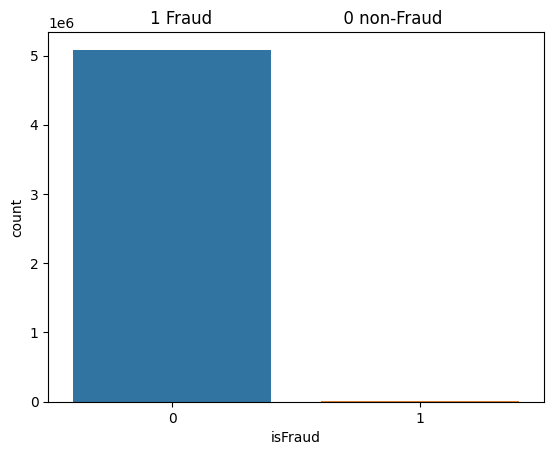

In [10]:
sns.countplot(df,x='isFraud')
plt.title("1 Fraud                         0 non-Fraud")

Text(0.5, 1.0, 'Frequencies of transaction types')

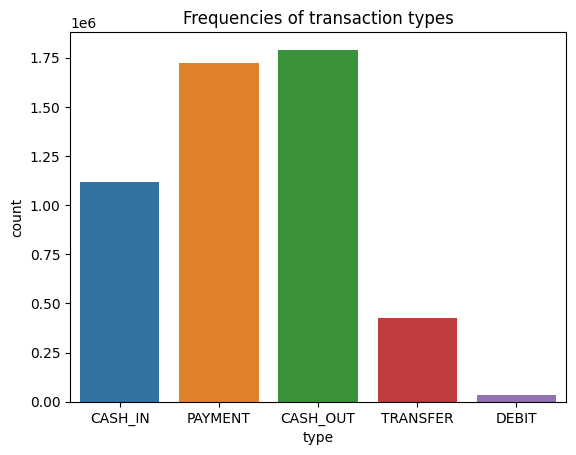

In [11]:
sns.countplot(df,x='type')
plt.title("Frequencies of transaction types")

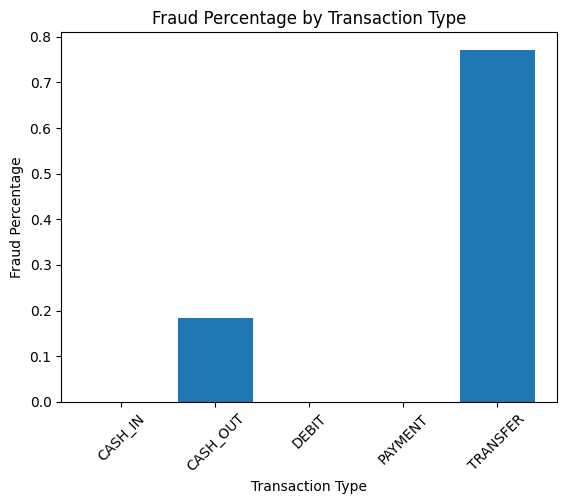

In [12]:
# Group by "TransactionType" and calculate the mean of "isFraud"
fraud_percentage_by_type = df.groupby('type')['isFraud'].mean() * 100
# Create a bar plot
plt.bar(fraud_percentage_by_type.index, fraud_percentage_by_type.values)
# Adding labels and title
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Percentage')
plt.title('Fraud Percentage by Transaction Type')

# Rotate x labels for better readability
plt.xticks(rotation=45)

# Display the plot
#plt.tight_layout()
plt.show()

In [13]:
data = df.loc[df['type'].isin(['CASH_OUT', 'TRANSFER'])]
print('The new data now has ', len(data), ' transactions.')

The new data now has  2217024  transactions.


In [14]:
print('Number of transactions where the transaction amount is negative: ' +
str(sum(data['amount'] < 0)))

Number of transactions where the transaction amount is negative: 0


In [15]:
print('Number of transactions where the transaction amount is equal to zero: ' +
str(sum(data['amount'] == 0)))

Number of transactions where the transaction amount is equal to zero: 14


Percentage of transactions where originators initial balance is 0: 47.23


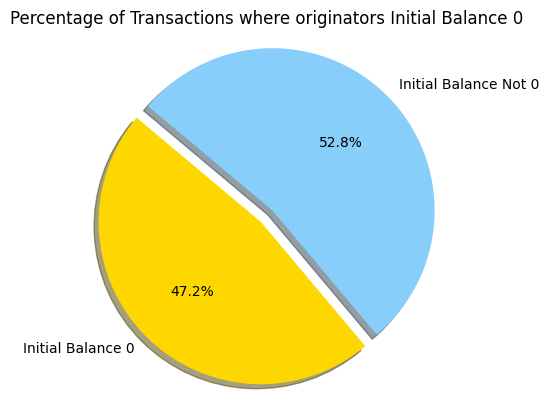

In [16]:
no_Ofzero=sum(data['oldbalanceOrg']==0)
total=len(data['oldbalanceDest'])
percentage=(no_Ofzero/total)*100
print(f"Percentage of transactions where originators initial balance is 0: {percentage:.2f}")


labels = ['Initial Balance 0', 'Initial Balance Not 0']
sizes = [percentage, 100 - percentage]
colors = ['gold', 'lightskyblue']
explode = (0.1, 0)  # explode the 1st slice

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.title("Percentage of Transactions where originators Initial Balance 0")
plt.show()

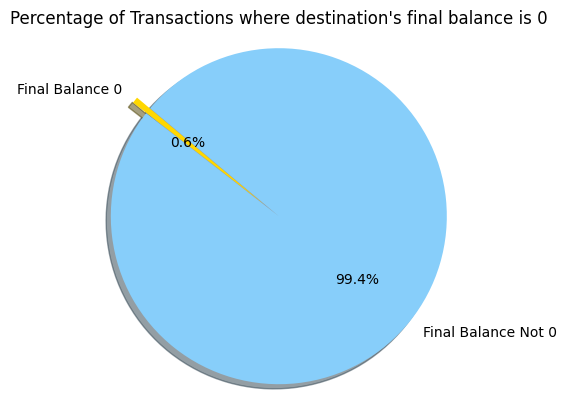

In [17]:
no_Ofzero=sum(data['newbalanceDest']==0)
total=len(data['newbalanceDest'])
percentage=(no_Ofzero/total)*100
#print(f"Percentage of transactions where  destination's final balance is 0:{percantage:.2f}")

#pie plot
import matplotlib.pyplot as plt

# Data
labels = ['Final Balance 0', 'Final Balance Not 0']
sizes = [percentage, 100 - percentage]  # Corrected calculation
colors = ['gold', 'lightskyblue']
explode = (0.1, 0)  # Explode the first slice

# Create pie plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title("Percentage of Transactions where destination's final balance is 0")

# Display the plot
plt.show()

% transactions where originator balances are not accurately captured:93.70 


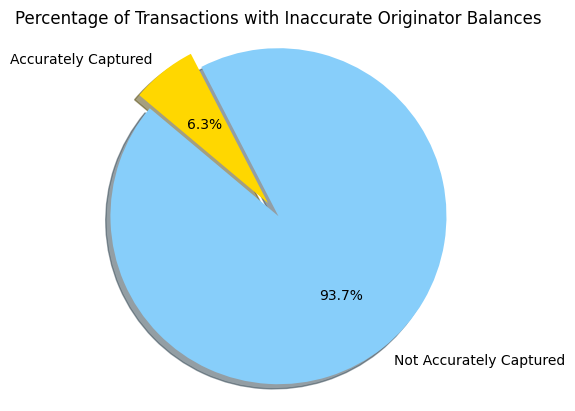

In [18]:
tolerance = 1e-6
not_accuratly_captured=sum(np.abs(data['oldbalanceOrg']-data['amount']==data['newbalanceOrig'])<tolerance)
total=len(data['newbalanceOrig'])
percentage=(not_accuratly_captured/total)*100
print(f"% transactions where originator balances are not accurately captured:{percentage:.2f} ")


labels = [ 'Not Accurately Captured','Accurately Captured']
sizes = [percentage,100 - percentage ]
colors = ['lightskyblue', 'gold']
explode = (0, 0.1)  # Explode the "Not Accurately Captured" slice

# Create pie plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title("Percentage of Transactions with Inaccurate Originator Balances")

# Display the plot
plt.show()

% transactions where destination's balances are not accurately captured:42.08 


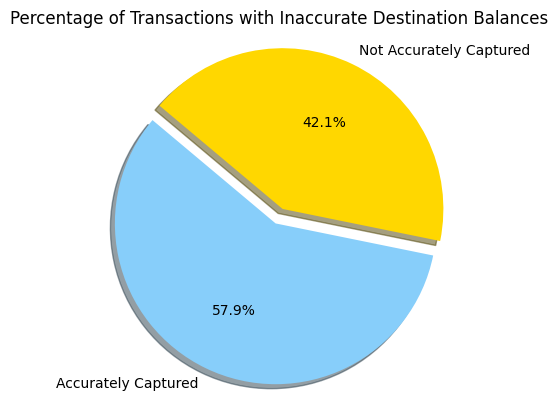

In [19]:
tolerance = 1e-6
not_accuratly_captured=sum(np.abs(data['amount']+data['oldbalanceDest']==data['newbalanceDest'])<tolerance)
total=len(data['newbalanceDest'])
percentage=(not_accuratly_captured/total)*100
print(f"% transactions where destination's balances are not accurately captured:{percentage:.2f} ")


# Data for the pie plot
labels = ["Accurately Captured", "Not Accurately Captured"]
sizes = [100 - percentage, percentage]
colors = ['lightskyblue', 'gold']
explode = (0, 0.1)  # Explode the "Not Accurately Captured" slice

# Create pie plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title("Percentage of Transactions with Inaccurate Destination Balances")

# Display the plot
plt.show()

6593
36
% of fraudulent transactions where initial balance of originator is 0: 0.546034


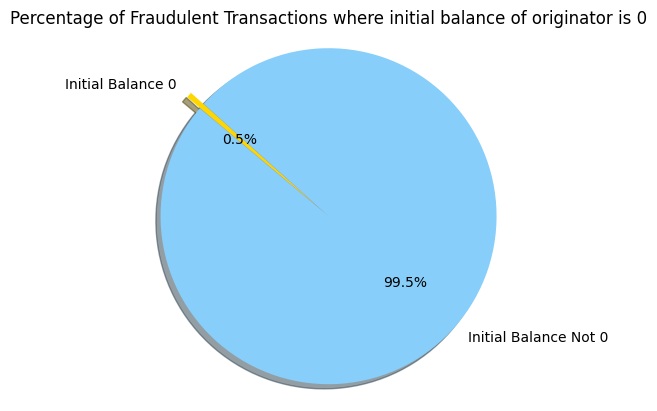

In [20]:
fraud_count=0
for i in range(len(data['isFraud'])):
  if data['isFraud'].values[i] ==1 :
    fraud_count=fraud_count+1
print(fraud_count)

value_count=0
for i in range(len(data['isFraud'])):
  if data['isFraud'].values[i] ==1 and data['oldbalanceOrg'].values[i]==0 :
    value_count=value_count+1
print(value_count)


percentage=(value_count/fraud_count)*100
print(f"% of fraudulent transactions where initial balance of originator is 0: {percentage:2f}")

labels = ["Initial Balance Not 0", "Initial Balance 0"]
sizes = [100 - percentage, percentage]
colors = ['lightskyblue', 'gold']
explode = (0, 0.1)  # Explode the "Initial Balance 0" slice

# Create pie plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title("Percentage of Fraudulent Transactions where initial balance of originator is 0")

# Display the plot
plt.show()

2210431
1047163
% of non fraudulent transactions where initial balance of originator is 0: 47.373702


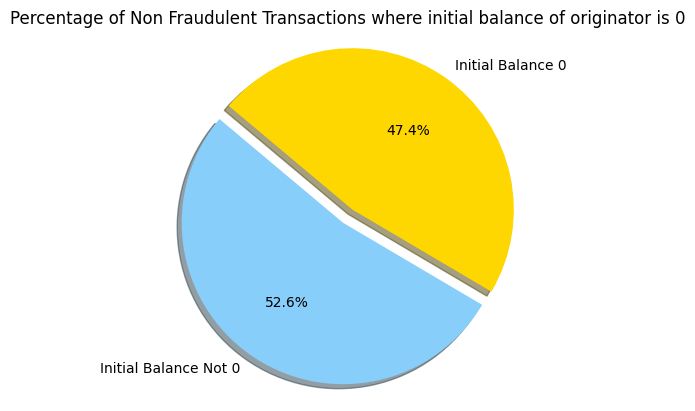

In [22]:
fraud_count=0
for i in range(len(data['isFraud'])):
  if data['isFraud'].values[i] ==0 :
    fraud_count=fraud_count+1
print(fraud_count)

value_count=0
for i in range(len(data['isFraud'])):
  if data['isFraud'].values[i] ==0 and data['oldbalanceOrg'].values[i]==0 :
    value_count=value_count+1
print(value_count)


percentage=(value_count/fraud_count)*100
print(f"% of non fraudulent transactions where initial balance of originator is 0: {percentage:2f}")

labels = ["Initial Balance Not 0", "Initial Balance 0"]
sizes = [100 - percentage, percentage]
colors = ['lightskyblue', 'gold']
explode = (0, 0.1)  # Explode the "Initial Balance 0" slice

# Create pie plot
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.001f%%', shadow=True, startangle=140)

plt.axis('equal')  # Equal aspect ratio ensures the pie is drawn as a circle.
plt.title("Percentage of Non Fraudulent Transactions where initial balance of originator is 0")

# Display the plot
plt.show()

In [23]:
data1 = data.drop(['nameOrig', 'nameDest','isFlaggedFraud','step'], axis=1)
print(data1.head())
len(data1)

        type     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
3   CASH_OUT  527616.51       180216.0            0.00        92157.10   
4   TRANSFER  206067.85            0.0            0.00      2131494.48   
6   CASH_OUT   15241.42        45285.0        30043.58       355775.87   
10  CASH_OUT  460159.75            0.0            0.00      1602337.92   
11  CASH_OUT   39570.59        30591.0            0.00            0.00   

    newbalanceDest  isFraud  
3        619773.61        0  
4       2337562.32        0  
6        652863.91        0  
10      2062497.67        0  
11        39570.59        0  


2217024

In [24]:
from sklearn.model_selection import train_test_split
train_data,test_data=train_test_split(data1,test_size=0.3,random_state=21)
print("len of train data",len(train_data))
print("len of test data",len(test_data))

len of train data 1551916
len of test data 665108


In [25]:
#training data
x_train=train_data.drop(["isFraud"],axis=1)
y_train=train_data["isFraud"]



#testing data
x_test=test_data.drop("isFraud",axis=1)
y_test=test_data["isFraud"]



print(type(y_train))

<class 'pandas.core.series.Series'>


In [26]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder

#numerical features
num_feats=x_train.drop("type",axis=1)
num_feats_pipe=Pipeline([
    ("scalar",MinMaxScaler())
    ])
num_feats_preprocessed=num_feats_pipe.fit_transform(num_feats)

#catagorical features
cat_feats=x_train[["type"]]
cat_feats_pipe=Pipeline([
    ("encoder",OneHotEncoder())
    ])
cat_feats_preprocessed=cat_feats_pipe.fit_transform(cat_feats)
print(num_feats)

            amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
4292035  241478.41            0.0            0.00       881618.43   
3115153   32691.90        34229.0         1537.10       103138.21   
1287010  291328.62            0.0            0.00       944281.25   
2643139  607555.17        71017.0            0.00            0.00   
3330726   69911.01            0.0            0.00      1152896.38   
...            ...            ...             ...             ...   
146054   414507.55        90639.0            0.00       408333.66   
2594124    5475.68        28635.0        23159.32        24264.47   
1524247  435060.90            0.0            0.00       584681.98   
465778    69458.51            0.0            0.00     59498509.30   
4374813   74940.63            0.0            0.00      2645394.82   

         newbalanceDest  
4292035      1123096.84  
3115153       135830.10  
1287010      1235609.87  
2643139       607555.17  
3330726      1222807.39  
...            

In [27]:
from sklearn.compose import ColumnTransformer
num_list=list(num_feats)
cat_list=list(cat_feats)

final_pipeline=ColumnTransformer([
    ("num",num_feats_pipe,num_list),
    ("cat",cat_feats_pipe,cat_list)])
X_train_preprocessed=final_pipeline.fit_transform(x_train)
print(x_train)
X_train_preprocessed

X_test_preprocessed = final_pipeline.fit_transform(x_test)
X_test_preprocessed

             type     amount  oldbalanceOrg  newbalanceOrig  oldbalanceDest  \
4292035  CASH_OUT  241478.41            0.0            0.00       881618.43   
3115153  CASH_OUT   32691.90        34229.0         1537.10       103138.21   
1287010  CASH_OUT  291328.62            0.0            0.00       944281.25   
2643139  CASH_OUT  607555.17        71017.0            0.00            0.00   
3330726  CASH_OUT   69911.01            0.0            0.00      1152896.38   
...           ...        ...            ...             ...             ...   
146054   CASH_OUT  414507.55        90639.0            0.00       408333.66   
2594124  CASH_OUT    5475.68        28635.0        23159.32        24264.47   
1524247  CASH_OUT  435060.90            0.0            0.00       584681.98   
465778   CASH_OUT   69458.51            0.0            0.00     59498509.30   
4374813  CASH_OUT   74940.63            0.0            0.00      2645394.82   

         newbalanceDest  
4292035      1123096.84  

array([[2.66027266e-03, 1.31455881e-05, 0.00000000e+00, ...,
        7.49842273e-04, 1.00000000e+00, 0.00000000e+00],
       [3.31434548e-03, 0.00000000e+00, 0.00000000e+00, ...,
        4.71173097e-02, 1.00000000e+00, 0.00000000e+00],
       [4.94161563e-03, 0.00000000e+00, 0.00000000e+00, ...,
        7.29071836e-03, 1.00000000e+00, 0.00000000e+00],
       ...,
       [4.33062970e-04, 0.00000000e+00, 0.00000000e+00, ...,
        2.78026988e-03, 1.00000000e+00, 0.00000000e+00],
       [4.96065939e-03, 0.00000000e+00, 0.00000000e+00, ...,
        1.51836364e-02, 0.00000000e+00, 1.00000000e+00],
       [2.57146813e-04, 0.00000000e+00, 0.00000000e+00, ...,
        2.00722689e-02, 1.00000000e+00, 0.00000000e+00]],
      shape=(665108, 7))

In [28]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [29]:
log_model=model.fit(X_train_preprocessed,y_train)

In [30]:
y_train_pred = log_model.predict(X_train_preprocessed)
y_train_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(1551916,))

In [31]:
y_test_pred=log_model.predict(X_test_preprocessed)
y_test_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(665108,))

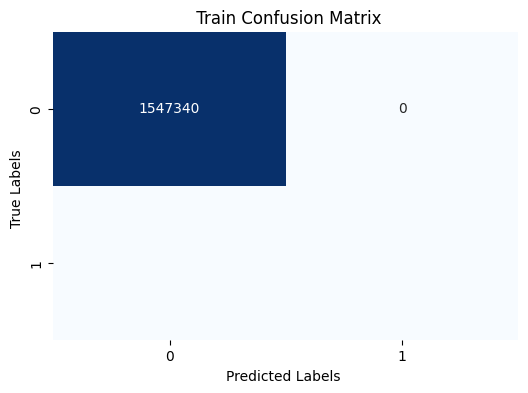

In [32]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Train Confusion Matrix")
plt.show()

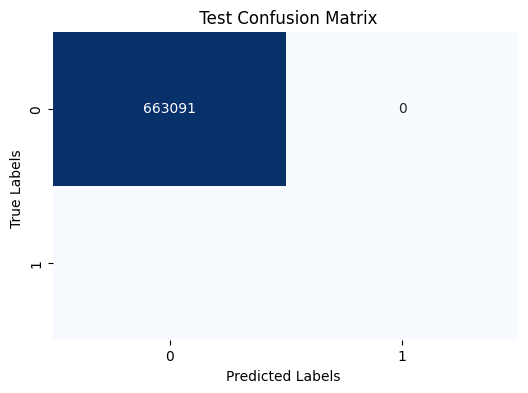

In [33]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Test Confusion Matrix")
plt.show()

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=21)

# Train the model on your training data
rf_model.fit(X_train_preprocessed,y_train)

# Make predictions on your testing data
y_test_pred_rf = rf_model.predict(X_test_preprocessed)

In [38]:
y_train_pred_rf = rf_model.predict(X_train_preprocessed)
y_train_pred_rf
y_test_pred_rf

array([0, 0, 0, ..., 0, 0, 0], shape=(665108,))

In [39]:
from sklearn.metrics import f1_score
f1 = f1_score(y_train,y_train_pred_rf)
print("F1 Score of train data:", f1)

f2 = f1_score(y_test,y_test_pred_rf)
print("F1 Score of test data:", f2)

F1 Score of train data: 0.9998907223254289
F1 Score of test data: 0.2397428625449045


In [40]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_test_pred_rf)
print(report)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    663091
           1       0.14      0.94      0.24      2017

    accuracy                           0.98    665108
   macro avg       0.57      0.96      0.62    665108
weighted avg       1.00      0.98      0.99    665108



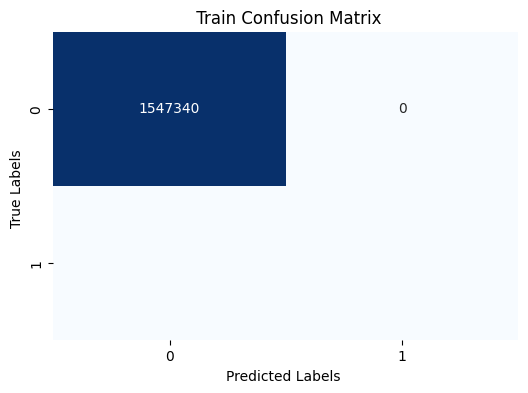

In [41]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_train, y_train_pred_rf)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Train Confusion Matrix")
plt.show()


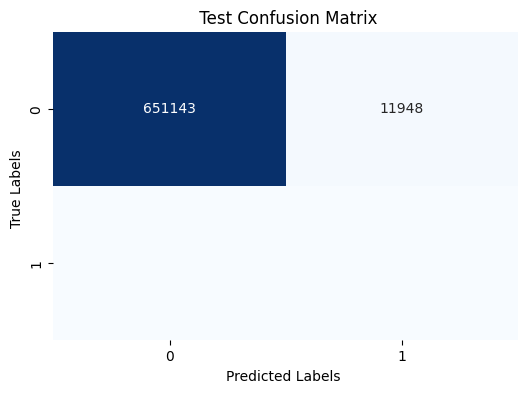

In [42]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_test_pred_rf)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Test Confusion Matrix")
plt.show()

In [43]:
import xgboost as xgb

# Create an XGBoost classifier
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42)

# Train the model on your training data
xgb_model.fit(X_train_preprocessed,y_train)

# Make predictions on your testing data
y_test_pred_xgb = xgb_model.predict(X_test_preprocessed)

In [44]:
y_train_pred_xgb = rf_model.predict(X_train_preprocessed)
y_train_pred_xgb
y_test_pred_xgb

array([0, 0, 0, ..., 0, 0, 0], shape=(665108,))

In [45]:
f1 = f1_score(y_train,y_train_pred_xgb)
print("F1 Score of train data:", f1)

f2 = f1_score(y_test,y_test_pred_xgb)
print("F1 Score of test data:", f2)

F1 Score of train data: 0.9998907223254289
F1 Score of test data: 0.1479883233912933


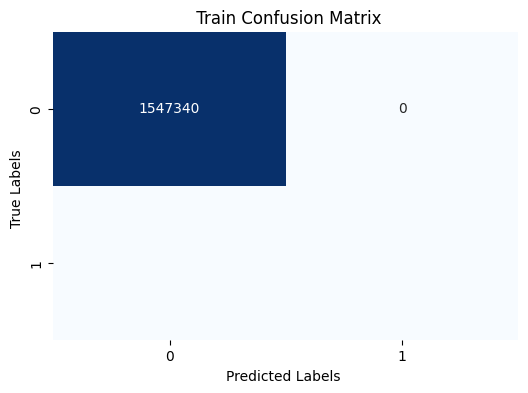

In [46]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_train, y_train_pred_xgb)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Train Confusion Matrix")
plt.show()


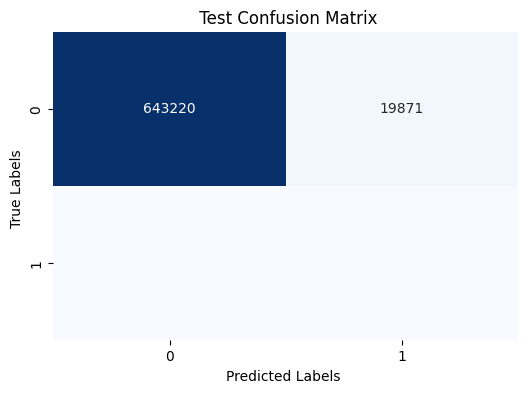

In [47]:
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_test_pred_xgb)

# Create a heatmap to visualize the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels ")
plt.ylabel("True Labels ")
plt.title(" Test Confusion Matrix")
plt.show()